# Detecting inventory structure: book of openings, or mixed folder?

Archival images and transcriptions are organised as `<institute_id>/<archive_id>/<inventory_num_id>/<scan>`
(in most cases `archive_id` extends `institute_id`, and `inventory_num_id` extends `archive_id`).
This notebook demonstrates the inventory-level extension of `archival_structures.analysis.opening_detection`:
deciding whether an *entire inventory number* represents a **book of openings** (predominantly
two-page spreads, usually with single-page covers at the start/end), or a **mixed** folder/booklet
(a mixture of single-page sheets, two-page openings, and odd-shaped sheets, with no one
consistent page size).

The approach only needs the PageXML `imageWidth`/`imageHeight` metadata (`scan.coords.width/height`)
-- no images required, though we show a couple where available. It groups scans by width
(`find_width_groups`), looks for a pair of groups consistent with a real single-page/opening
relationship (`identify_page_unit_widths`: roughly double the width, openings at least as
numerous as covers, both groups substantial, together explaining nearly all scans), and uses
that to classify both individual scans (`classify_page_types`: `single_page`/`opening`/`odd_shaped`)
and the inventory as a whole (`classify_inventory_structure`).

**On glued flaps**: some book scans show a sheet glued onto a page, masking the text behind it,
with the *next* scan showing the same opening with the sheet folded back to reveal the text.
Both states are photographed at the full opening width, so they don't disturb this width-based
approach -- a "book of openings" inventory simply ends up with more scans than physical openings,
which is expected.

This was validated against six real, independently-labelled inventory numbers (four books, two
mixed folders) below, matching the expected verdict on all six.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, STRUCTURE_BOOK_OF_OPENINGS, STRUCTURE_MIXED,
    PAGE_TYPE_SINGLE, PAGE_TYPE_OPENING, PAGE_TYPE_ODD,
)

PAGEXML_DIR = Path('../../data/PageXML')
IMAGE_DIR = Path('../../data/thumbs')

# six real inventory numbers, independently labelled by domain experts
INVENTORIES = [
    {'institute': 'NL-HaNA', 'archive': 'NL-HaNA_2.10.50', 'inventory_num': 'NL-HaNA_2.10.50_1',
     'expected': STRUCTURE_BOOK_OF_OPENINGS},
    {'institute': 'NL-HaNA', 'archive': 'NL-HaNA_2.10.50', 'inventory_num': 'NL-HaNA_2.10.50_85',
     'expected': STRUCTURE_BOOK_OF_OPENINGS},
    {'institute': 'NL-HaNA', 'archive': 'NL-HaNA_2.10.50', 'inventory_num': 'NL-HaNA_2.10.50_619',
     'expected': STRUCTURE_BOOK_OF_OPENINGS},
    {'institute': 'NL-HaNA', 'archive': 'NL-HaNA_1.05.06', 'inventory_num': 'NL-HaNA_1.05.06_1',
     'expected': STRUCTURE_BOOK_OF_OPENINGS},
    {'institute': 'NL-AsdSAA', 'archive': 'NL-AsdSAA_89', 'inventory_num': 'NL-AsdSAA_89_3.1',
     'expected': STRUCTURE_MIXED},
    {'institute': 'NL-HaNA', 'archive': 'NL-HaNA_1.05.06', 'inventory_num': 'NL-HaNA_1.05.06_2',
     'expected': STRUCTURE_MIXED},
]

## Load scans and classify each inventory

In [3]:
rows = []
results = {}
for inv in INVENTORIES:
    xml_dir = PAGEXML_DIR / inv['institute'] / inv['archive'] / inv['inventory_num']
    scans = [pagexml_parser.parse_pagexml_file(str(p)) for p in sorted(xml_dir.glob('*.xml'))]
    result = classify_inventory_structure(scans)
    results[inv['inventory_num']] = (scans, result)
    rows.append({
        'institute': inv['institute'], 'archive': inv['archive'], 'inventory_num': inv['inventory_num'],
        'n_scans': len(scans), 'expected': inv['expected'], 'detected': result.structure_type,
        'n_single': result.type_counts.get(PAGE_TYPE_SINGLE, 0),
        'n_opening': result.type_counts.get(PAGE_TYPE_OPENING, 0),
        'n_odd': result.type_counts.get(PAGE_TYPE_ODD, 0),
        'single_width': result.single_page_width, 'opening_width': result.opening_width,
    })

summary = pd.DataFrame(rows)
summary

,institute,archive,inventory_num,n_scans,expected,detected,n_single,n_opening,n_odd,single_width,opening_width
0,NL-HaNA,NL-HaNA_2.10.50,NL-HaNA_2.10.50_1,336,book_of_openings,book_of_openings,88,242,6,5000.0,7335.0
1,NL-HaNA,NL-HaNA_2.10.50,NL-HaNA_2.10.50_85,203,book_of_openings,book_of_openings,54,146,3,5000.0,7536.0
2,NL-HaNA,NL-HaNA_2.10.50,NL-HaNA_2.10.50_619,321,book_of_openings,book_of_openings,63,256,2,5000.0,8177.0
3,NL-HaNA,NL-HaNA_1.05.06,NL-HaNA_1.05.06_1,5,book_of_openings,book_of_openings,2,3,0,2507.5,4882.0
4,NL-AsdSAA,NL-AsdSAA_89,NL-AsdSAA_89_3.1,1035,mixed,mixed,0,0,1035,NaN,NaN
5,NL-HaNA,NL-HaNA_1.05.06,NL-HaNA_1.05.06_2,17,mixed,mixed,0,0,17,NaN,NaN


## Visualise: scan width per page, coloured by detected type

Blue = single page, green = opening, red = odd-shaped (or, for a `mixed` inventory where no
consistent single/opening pair was found at all, every scan -- there's no reference width to
compare to). The book inventories show a clean two-level step pattern; the mixed ones don't.

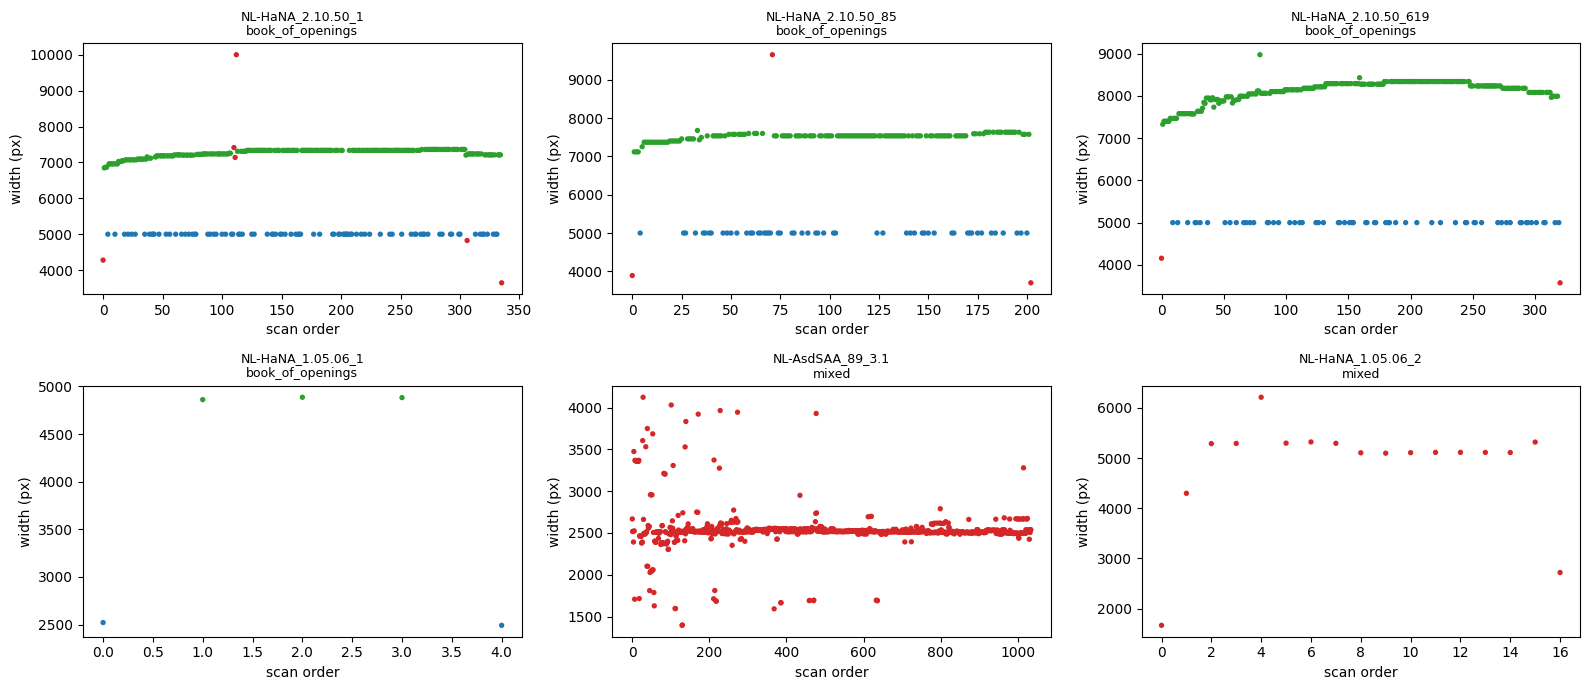

In [4]:
color_map = {PAGE_TYPE_SINGLE: 'tab:blue', PAGE_TYPE_OPENING: 'tab:green', PAGE_TYPE_ODD: 'tab:red'}

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, inv in zip(axes.flat, INVENTORIES):
    scans, result = results[inv['inventory_num']]
    widths = [scan.coords.width for scan in scans]
    colors = [color_map[result.page_types[scan.id]] for scan in scans]
    ax.scatter(range(len(scans)), widths, c=colors, s=8)
    ax.set_title(f"{inv['inventory_num']}\n{result.structure_type}", fontsize=9)
    ax.set_xlabel('scan order')
    ax.set_ylabel('width (px)')
plt.tight_layout()
plt.show()

## A visual sanity check, where thumbnails are available

`NL-HaNA_1.05.06_1` has thumbnails whose filenames directly match the PageXML filenames (most of
the other inventories above either have no thumbnails at all, or use thumbnail filenames that
don't correspond 1:1 to the PageXML filenames -- rather than guess at a mapping, we only show
images here where the correspondence is verified). The first scan is classified `single_page`,
the second `opening` -- compare the two.

NL-HaNA_1.05.06_1_0001.jpg: width=2522 height=3957 -> single_page


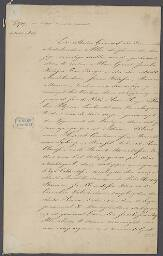

NL-HaNA_1.05.06_1_0002.jpg: width=4861 height=3963 -> opening


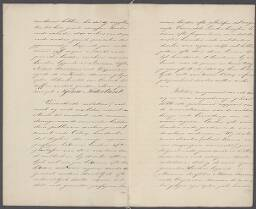

In [5]:
from PIL import Image

thumb_dir = IMAGE_DIR / 'NL-HaNA' / 'NL-HaNA_1.05.06' / '1'
scans, result = results['NL-HaNA_1.05.06_1']
for scan in scans[:2]:
    page_type = result.page_types[scan.id]
    scan_stem = Path(scan.id).stem  # scan.id ends in '.jpg'; the thumbnail is a '.tif'
    thumb_path = thumb_dir / f"{scan_stem}.tif"
    print(f"{scan.id}: width={scan.coords.width} height={scan.coords.height} -> {page_type}")
    if thumb_path.exists():
        display(Image.open(thumb_path).convert('RGB'))

## Summary

All six labelled inventories were classified correctly. The two mixed examples differ in
character -- `NL-AsdSAA_89_3.1` is a large folder with one dominant single-sheet size and a long
tail of unrelated sizes (no opening-width mode at all), while `NL-HaNA_1.05.06_2` is a small
17-scan booklet where no pair of width groups cleared the bar for being a *substantial*,
*proportionate* single-page/opening pair -- both correctly come out `mixed` even though they got
there differently, which is exactly why `identify_page_unit_widths` checks several conditions
together rather than a single threshold.